data/level3/copernicus/s5p/nrti/l3_co/CO_column_number_density.parquet


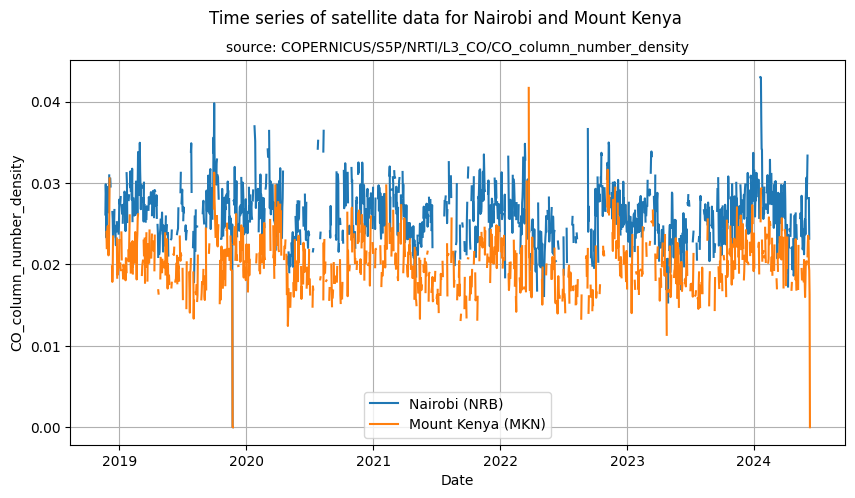

dte,nrb,mkn
date,f64,f64
2018-11-22,0.026129,null
2018-11-23,0.029849,null
2018-11-24,0.028535,null
2018-11-25,0.0233,0.023988
2018-11-26,0.029547,0.021997


In [73]:
import os
import polars as pl
import matplotlib.pyplot as plt
from processing.satellites import plot_data

# open satellite data file and plot data
collection = 'COPERNICUS/S5P/NRTI/L3_CO'
variable = 'CO_column_number_density'
file_co_column = os.path.join('data/level3', collection.lower(), f"{variable}.parquet")
print(file_co_column)
df_co_column = pl.read_parquet(file_co_column)
df_co_column = df_co_column.with_columns(pl.col('dte').dt.date())
plot_data(df_co_column, collection, variable, save=False)
df_co_column.head()

In [74]:
# compile insitu Picarro data
df = pl.DataFrame()
years = range(2019, 2025)
months = range(1, 13)
for year in years:
    for month in months:
        file = os.path.join('data/level1/', f"{year:2d}", f"{month:02d}", 'g2401.parquet')
        if os.path.exists(file):
            _df = pl.read_parquet(file)
            _df = _df.select(['dtm', 'CO_sync'])
            df = pl.concat([df, _df], how='diagonal')
df = df.with_columns(pl.col('dtm').dt.date().alias("dte"))
df_1d_insitu = df.group_by('dte', maintain_order=True).median()
df_1d_insitu.write_parquet(os.path.join('data/level2', 'CO_1d_insitu_median.parquet'))
df_1d_insitu.head()

dte,dtm,CO_sync
date,"datetime[μs, UTC]",f64
2021-09-09,2021-09-09 13:19:20 UTC,0.120907
2021-09-12,2021-09-12 12:19:30 UTC,0.130559
2021-09-13,2021-09-13 22:28:00 UTC,0.077287
2021-09-14,2021-09-14 13:31:45 UTC,0.132225
2021-09-15,2021-09-15 14:38:00 UTC,0.135349


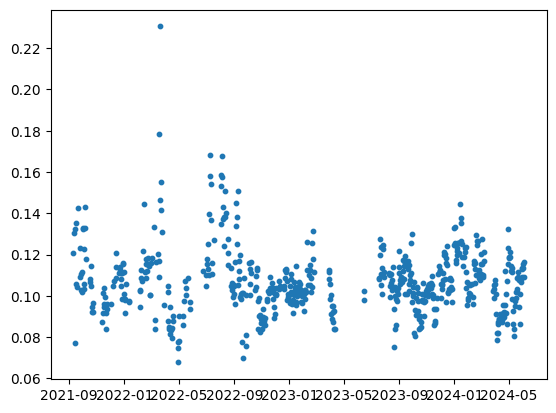

In [75]:
plt.scatter(df_1d_insitu['dtm'], df_1d_insitu['CO_sync'], s=10)

In [76]:
root = 'results/satellite_vs_insitu'
file = os.path.join(root, f"mkn_{collection.replace('/', '_')}_{variable}_vs_CO_insitu")

# join data frames
df = df_co_column.join(df_1d_insitu, on='dte', how='outer')
df.write_parquet(f"{file}.parquet")
df.describe()

statistic,dte,nrb,mkn,dte_right,dtm,CO_sync
str,str,f64,f64,str,str,f64
"""count""","""2028""",1382.0,1108.0,"""604""","""604""",604.0
"""null_count""","""0""",646.0,920.0,"""1424""","""1424""",1424.0
"""mean""","""2021-08-31""",0.026136,0.020095,"""2023-03-19""","""2023-03-20 01:…",0.106892
"""std""",null,0.003609,0.003373,null,null,0.01588
"""min""","""2018-11-22""",0.0,0.0,"""2021-09-09""","""2021-09-09 13:…",0.067681
"""25%""","""2020-04-12""",0.023925,0.017793,"""2022-08-08""","""2022-08-08 17:…",0.098013
"""50%""","""2021-09-01""",0.02613,0.020073,"""2023-02-20""","""2023-02-20 11:…",0.105076
"""75%""","""2023-01-20""",0.02819,0.022069,"""2023-12-08""","""2023-12-08 12:…",0.113747
"""max""","""2024-06-10""",0.042994,0.041684,"""2024-06-03""","""2024-06-03 01:…",0.230513


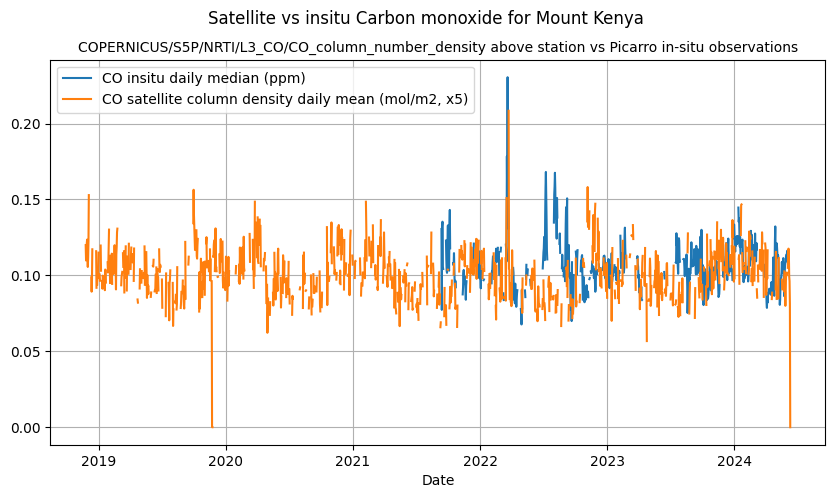

In [77]:
fig = plt.figure(figsize=(10, 5))
plt.plot(df['dte'], df['CO_sync'], label='CO insitu daily median (ppm)')
plt.plot(df['dte'], df['mkn']*5, label='CO satellite column density daily mean (mol/m2, x5)')
plt.xlabel('Date')
plt.suptitle("Satellite vs insitu Carbon monoxide for Mount Kenya")
plt.title(f"{collection}/{variable} above station vs Picarro in-situ observations", size=10)
plt.legend()
plt.grid(True)
plt.show()
fig.savefig(fname=f"{file}_timeseries.png", bbox_inches='tight')


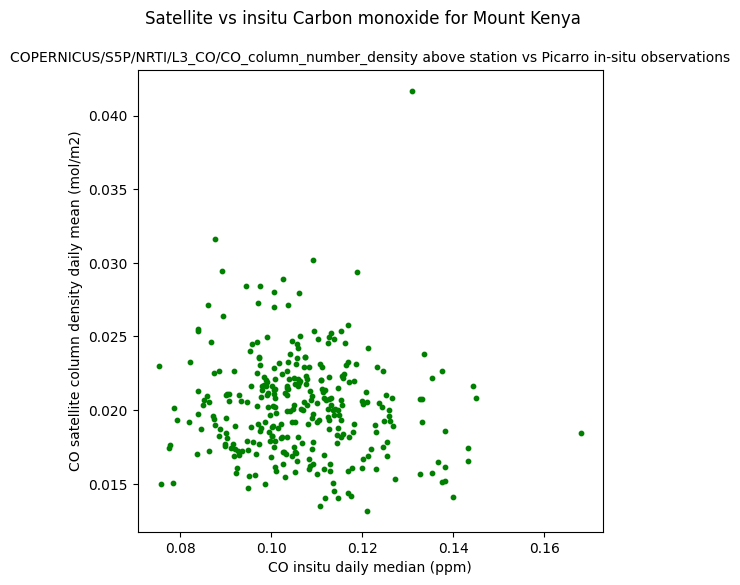

In [78]:
pdf = df.to_pandas()
fig = plt.figure(figsize=(6, 6))
plt.scatter(pdf['CO_sync'], pdf['mkn'], s=10, c='green')
plt.xlabel('CO insitu daily median (ppm)')
plt.ylabel('CO satellite column density daily mean (mol/m2)')
plt.suptitle("Satellite vs insitu Carbon monoxide for Mount Kenya")
plt.title(f"{collection}/{variable} above station vs Picarro in-situ observations", size=10)
plt.show()
fig.savefig(fname=f"{file}_correlation.png", bbox_inches='tight')